# 🏥 Healthcare Predictive Analytics — Disease Risk Detection

**Goal:** Predict the risk of diseases (Diabetes & Heart Disease) using machine learning.

**Datasets:** Loaded directly from reliable public URLs (Kaggle mirrors / UCI raw)

**Pipeline:**
1. 📦 Install & Import
2. 📂 Load Datasets (direct URL — no API needed)
3. 🔍 Exploratory Data Analysis (EDA)
4. 🧹 Data Preprocessing & Normalization
5. 🤖 Train Multiple Classification Models
6. 📊 Model Evaluation & Comparison
7. 🔬 Feature Importance + SHAP Analysis
8. 🔮 Interactive Risk Prediction Tool
9. 🔒 Ethical & Privacy Framework
10. 📝 Final Summary

---
> ⚠️ **Disclaimer:** This notebook is for **educational purposes only**. It does NOT constitute medical advice. Always consult a licensed medical professional for health concerns.

## 📦 Step 1: Install & Import Libraries

In [1]:
!pip install -q shap scikit-learn pandas numpy matplotlib seaborn plotly

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

import shap

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Step 2: Load Datasets (Direct URL — No API Required)

In [3]:
# ─────────────────────────────────────────────────────────────
#  Dataset 1 – Pima Indians Diabetes
#  Source: Raw CSV hosted on GitHub (original Kaggle/UCI data)
# ─────────────────────────────────────────────────────────────
DIABETES_URL = (
    'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
)
DIABETES_COLS = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

print('📥 Loading Pima Indians Diabetes dataset...')
diabetes_df = pd.read_csv(DIABETES_URL, header=None, names=DIABETES_COLS)
print(f'   Shape: {diabetes_df.shape}')
print(f'   Positive cases: {diabetes_df["Outcome"].sum()} ({diabetes_df["Outcome"].mean()*100:.1f}%)')
diabetes_df.head()

📥 Loading Pima Indians Diabetes dataset...
   Shape: (768, 9)
   Positive cases: 268 (34.9%)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
# ─────────────────────────────────────────────────────────────
#  Dataset 2 – Cleveland Heart Disease
#  Source: Reliable GitHub raw CSV (UCI Cleveland data)
# ─────────────────────────────────────────────────────────────
import io, requests

HEART_URL = (
    'https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart_disease.csv'
)

print('📥 Loading Heart Disease dataset...')
try:
    heart_df = pd.read_csv(HEART_URL)
except Exception:
    # Fallback: build Cleveland dataset from UCI raw .data file
    UCI_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
    cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
            'thalach','exang','oldpeak','slope','ca','thal','target']
    response = requests.get(UCI_URL)
    heart_df = pd.read_csv(
        io.StringIO(response.text),
        header=None, names=cols,
        na_values='?'          # UCI uses '?' for missing values
    )

# Binarise target: 0 = No disease, 1 = Disease
heart_df['target'] = (heart_df['target'].astype(float) > 0).astype(int)

# Drop rows where all values are NaN (safety)
heart_df.dropna(how='all', inplace=True)
heart_df.reset_index(drop=True, inplace=True)

print(f'   Shape: {heart_df.shape}')
print(f'   Positive cases: {heart_df["target"].sum()} ({heart_df["target"].mean()*100:.1f}%)')
heart_df.head()

📥 Loading Heart Disease dataset...
   Shape: (303, 14)
   Positive cases: 165 (54.5%)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:
# Quick sanity check
print('=== Diabetes columns:', diabetes_df.columns.tolist())
print('=== Heart columns:   ', heart_df.columns.tolist())
print('\nDiabetes dtypes:\n', diabetes_df.dtypes)
print('\nHeart dtypes:\n', heart_df.dtypes)

=== Diabetes columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
=== Heart columns:    ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Diabetes dtypes:
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Heart dtypes:
 age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


## 🔍 Step 3: Exploratory Data Analysis (EDA)

In [9]:
def quick_summary(df, name):
    print(f'\n{"="*55}')
    print(f'  📋 {name}')
    print(f'{"="*55}')
    print(f'  Rows: {df.shape[0]}   Columns: {df.shape[1]}')
    print(f'  Missing values: {df.isnull().sum().sum()}')
    print(f'  Duplicate rows: {df.duplicated().sum()}')
    display(df.describe().round(2))

quick_summary(diabetes_df, 'Diabetes Dataset')
quick_summary(heart_df,    'Heart Disease Dataset')


  📋 Diabetes Dataset
  Rows: 768   Columns: 9
  Missing values: 0
  Duplicate rows: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00



  📋 Heart Disease Dataset
  Rows: 303   Columns: 14
  Missing values: 0
  Duplicate rows: 1


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


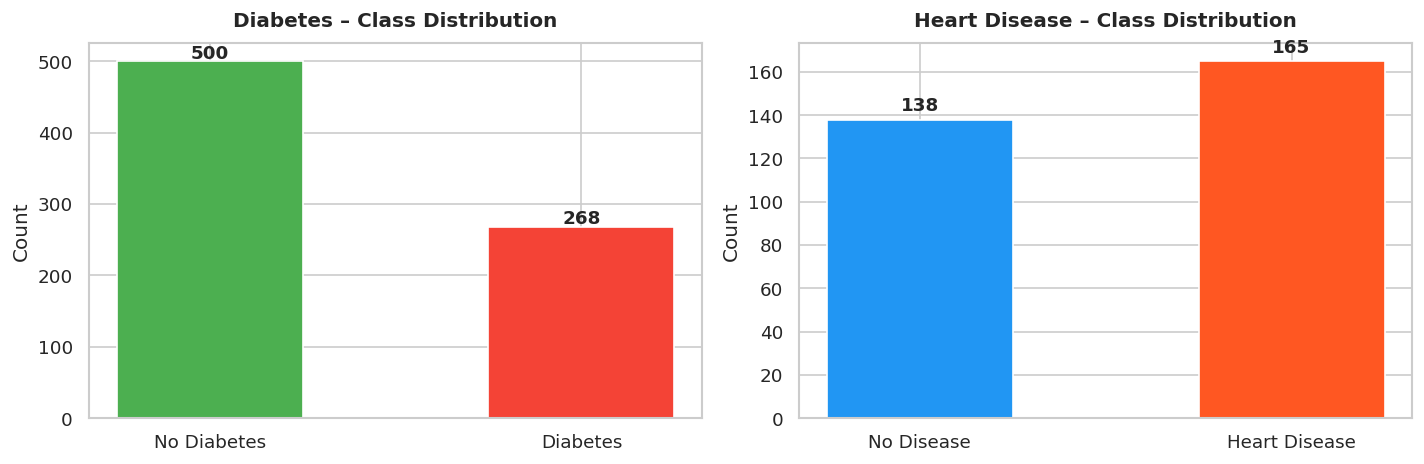

In [10]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (target, labels, colors, title) in zip(axes, [
    (diabetes_df['Outcome'], ['No Diabetes','Diabetes'],     ['#4CAF50','#F44336'], 'Diabetes'),
    (heart_df['target'],     ['No Disease', 'Heart Disease'],['#2196F3','#FF5722'], 'Heart Disease'),
]):
    counts = target.value_counts().sort_index()
    bars = ax.bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
    ax.set_title(f'{title} – Class Distribution', fontweight='bold', pad=10)
    ax.set_ylabel('Count')
    for bar, cnt in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+4,
                str(cnt), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

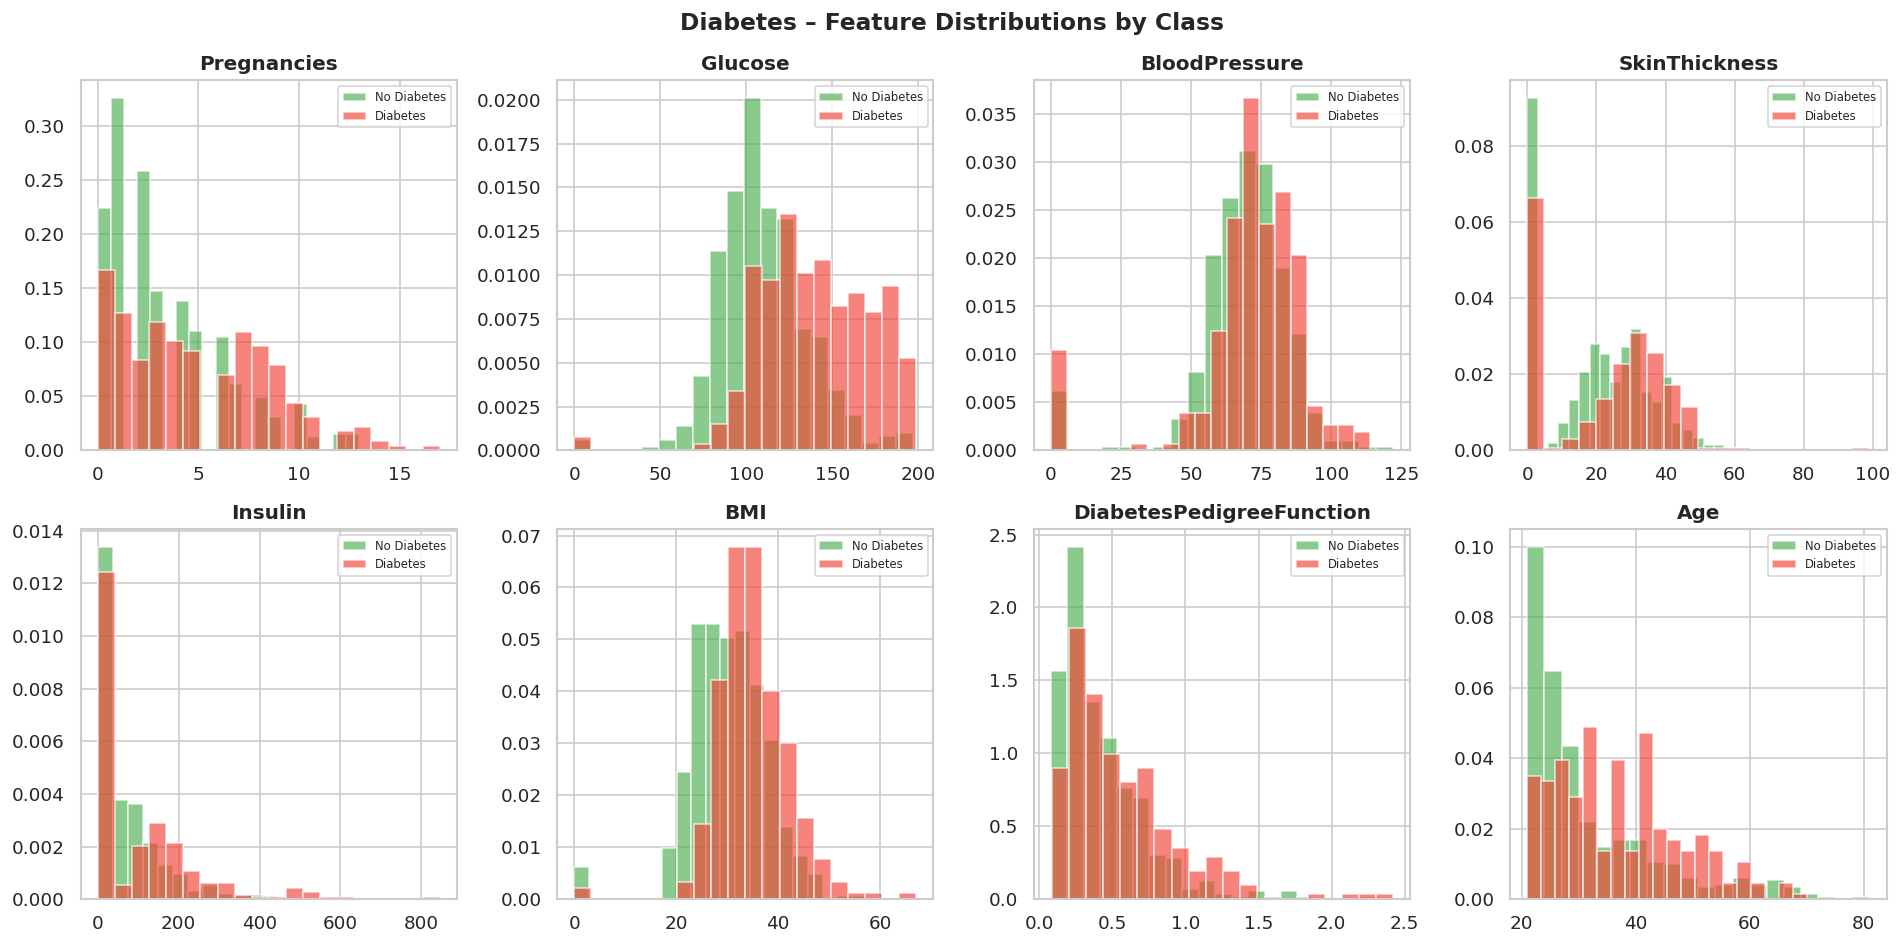

In [11]:
# Feature distributions by class – Diabetes
diab_feats = [c for c in diabetes_df.columns if c != 'Outcome']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(diab_feats):
    ax = axes[i]
    for label, color, name in [(0,'#4CAF50','No Diabetes'),(1,'#F44336','Diabetes')]:
        data = diabetes_df[diabetes_df['Outcome']==label][feat].dropna()
        ax.hist(data, bins=20, alpha=0.65, color=color, label=name, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=7)

plt.suptitle('Diabetes – Feature Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

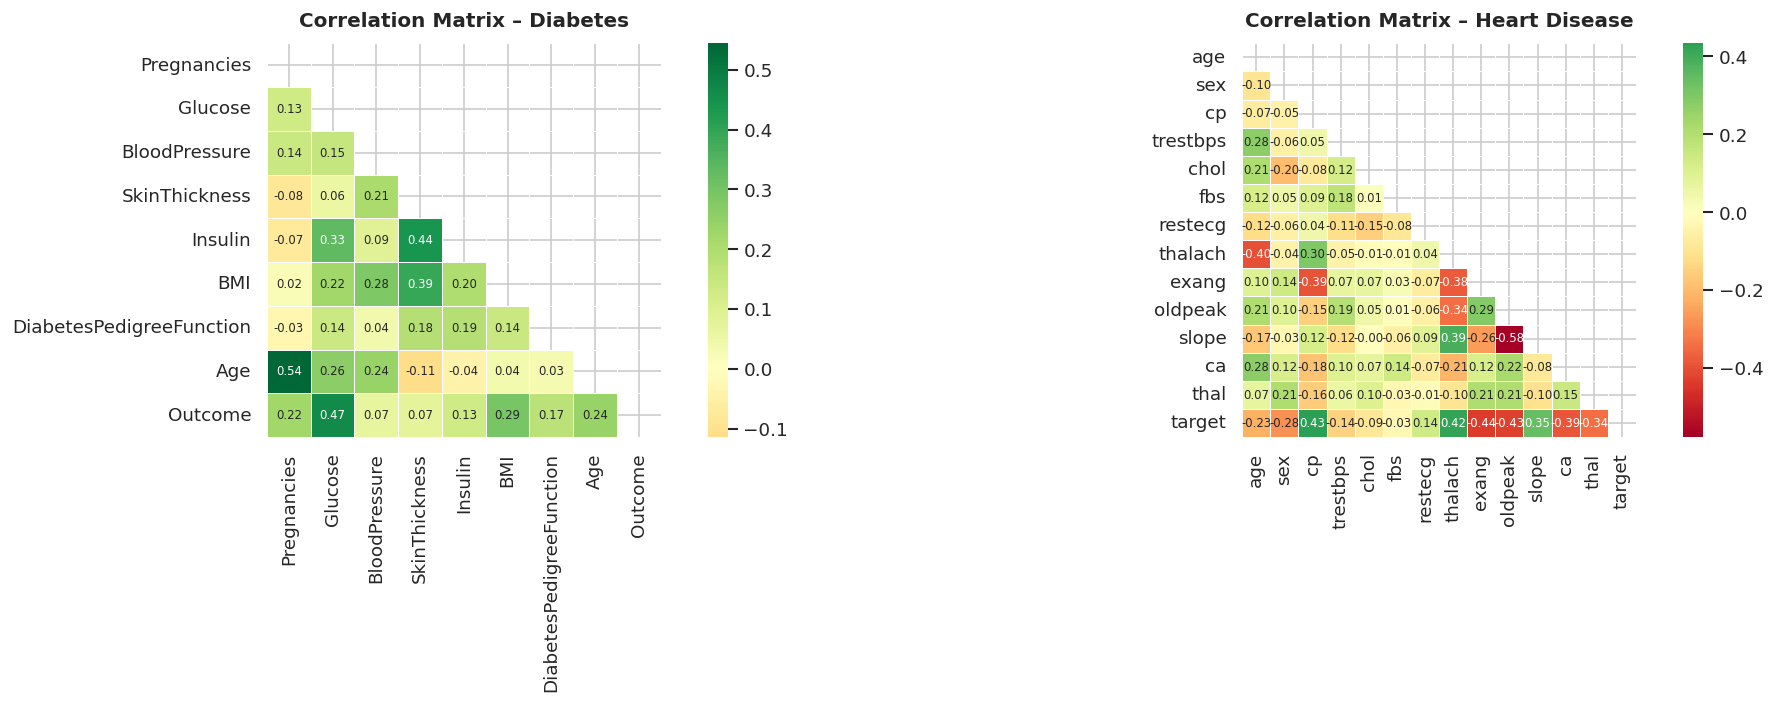

In [12]:
# Correlation heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, (df, title) in zip(axes, [
    (diabetes_df, 'Diabetes'),
    (heart_df,    'Heart Disease'),
]):
    corr = df.corr(numeric_only=True)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
                center=0, ax=ax, square=True, linewidths=0.5, annot_kws={'size':7})
    ax.set_title(f'Correlation Matrix – {title}', fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

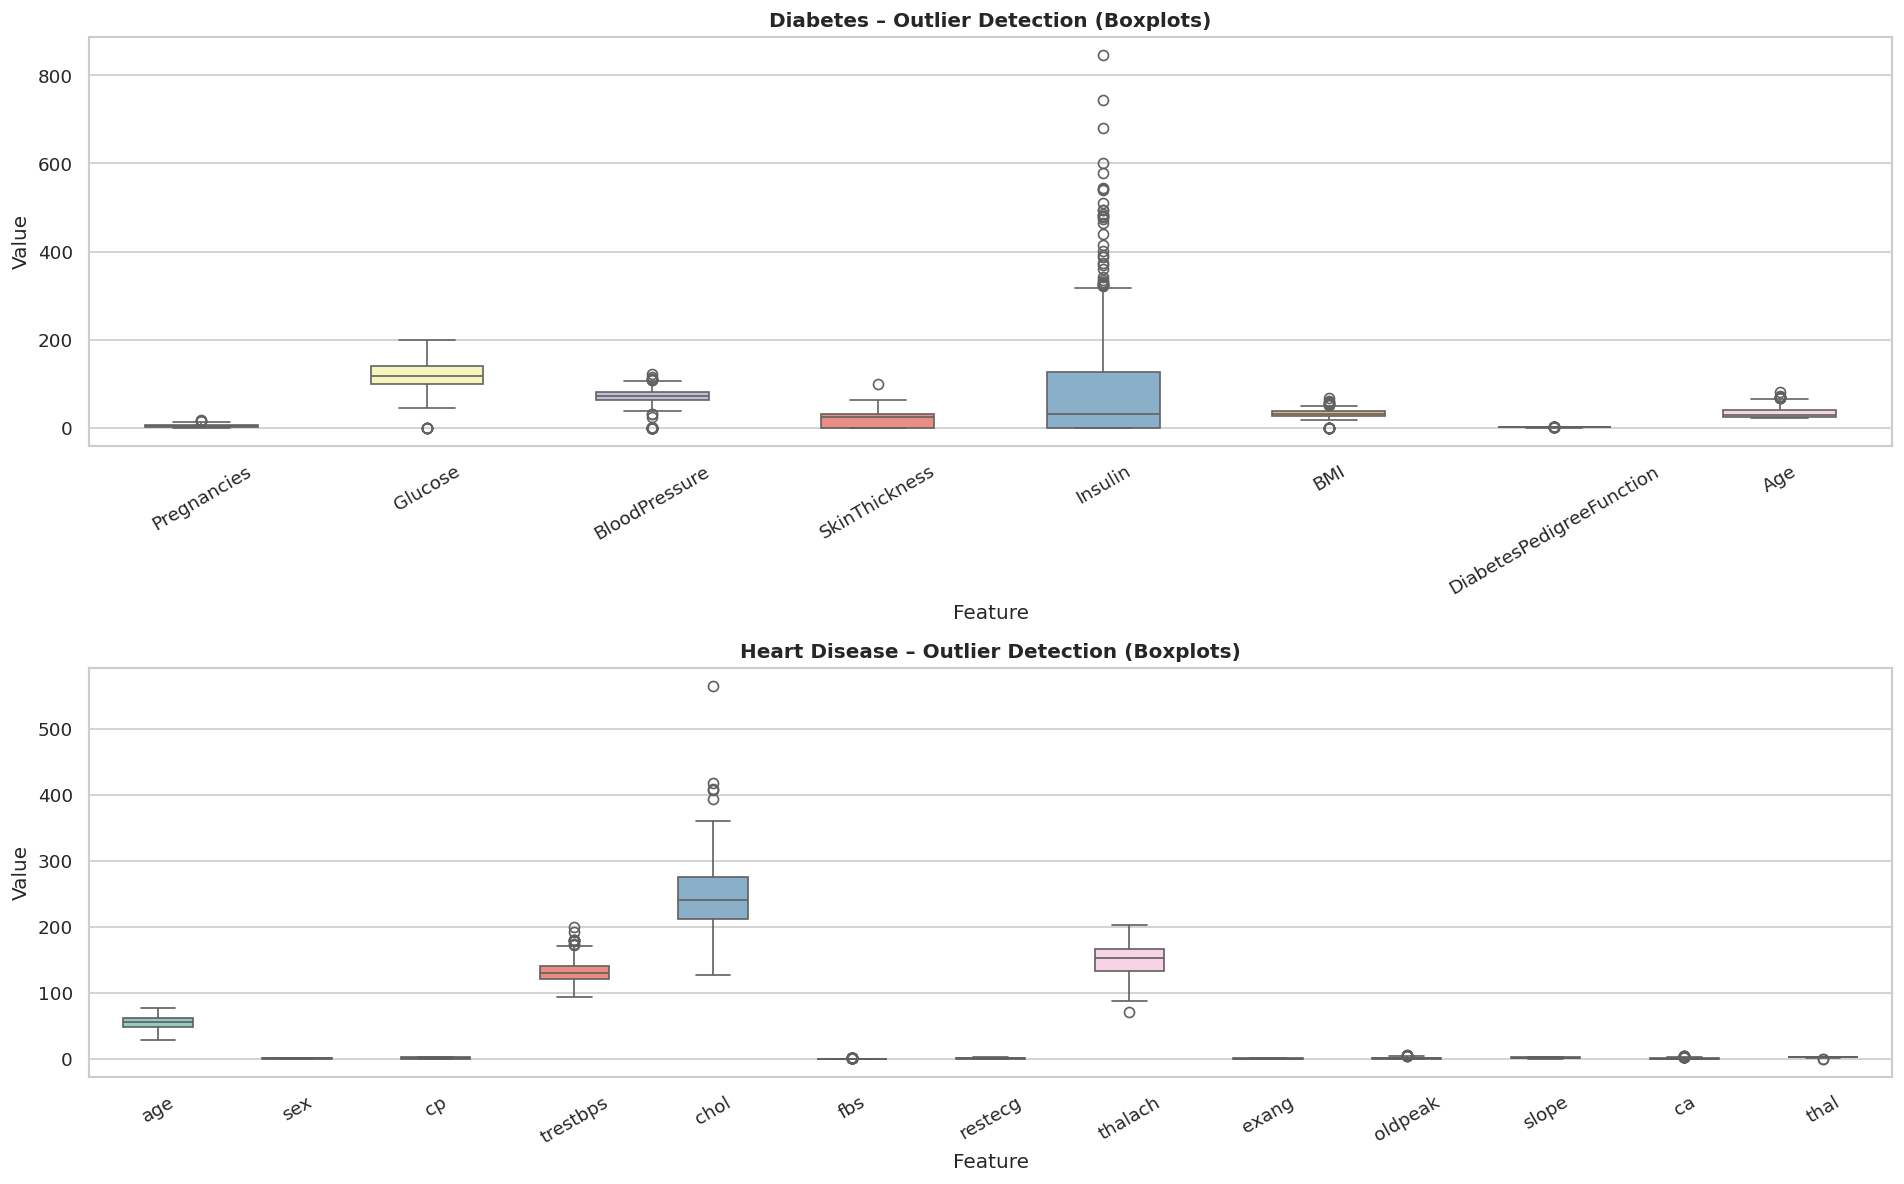

In [13]:
# Boxplots for outlier detection
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for ax, (df, target_col, title) in zip(axes, [
    (diabetes_df, 'Outcome', 'Diabetes'),
    (heart_df,    'target',  'Heart Disease'),
]):
    feats = [c for c in df.columns if c != target_col]
    melt  = df[feats].melt(var_name='Feature', value_name='Value')
    sns.boxplot(data=melt, x='Feature', y='Value', ax=ax, palette='Set3', width=0.5)
    ax.set_title(f'{title} – Outlier Detection (Boxplots)', fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 🧹 Step 4: Data Preprocessing & Normalization

In [14]:
def preprocess(df, target_col, zero_invalid_cols=None):
    """
    Full preprocessing pipeline:
    1. Replace biologically-impossible zeros → NaN
    2. Median imputation
    3. IQR outlier clipping
    4. Stratified train/test split
    5. StandardScaler normalisation (fit on train only)
    """
    X = df.drop(columns=[target_col]).copy()
    y = df[target_col].copy()
    feature_names = X.columns.tolist()

    # 1. Zero → NaN for clinically invalid zeros
    if zero_invalid_cols:
        for col in zero_invalid_cols:
            if col in X.columns:
                X[col] = X[col].replace(0, np.nan)

    # 2. Median imputation
    imputer = SimpleImputer(strategy='median')
    X_imp = pd.DataFrame(imputer.fit_transform(X), columns=feature_names)

    # 3. IQR clipping (winsorize at 1.5×IQR)
    for col in feature_names:
        Q1, Q3 = X_imp[col].quantile(0.25), X_imp[col].quantile(0.75)
        IQR = Q3 - Q1
        X_imp[col] = X_imp[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

    # 4. Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X_imp, y, test_size=0.2, random_state=SEED, stratify=y
    )

    # 5. Standardise
    scaler = StandardScaler()
    X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names)
    X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=feature_names)

    print(f'  Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}')
    print(f'  Class balance (train) – 0: {(y_train==0).sum()}  1: {(y_train==1).sum()}')
    return (
        X_train_sc, X_test_sc,
        y_train.reset_index(drop=True), y_test.reset_index(drop=True),
        scaler, feature_names, X_imp
    )

# Columns where 0 is biologically impossible (Diabetes)
DIAB_ZERO_INVALID = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

print('=== Diabetes ===')
Xtr_d, Xte_d, ytr_d, yte_d, scaler_d, feats_d, _ = preprocess(
    diabetes_df, 'Outcome', zero_invalid_cols=DIAB_ZERO_INVALID
)

print('\n=== Heart Disease ===')
Xtr_h, Xte_h, ytr_h, yte_h, scaler_h, feats_h, _ = preprocess(
    heart_df, 'target'
)

print('\n✅ Preprocessing complete!')

=== Diabetes ===
  Train: (614, 8)  |  Test: (154, 8)
  Class balance (train) – 0: 400  1: 214

=== Heart Disease ===
  Train: (242, 13)  |  Test: (61, 13)
  Class balance (train) – 0: 110  1: 132

✅ Preprocessing complete!


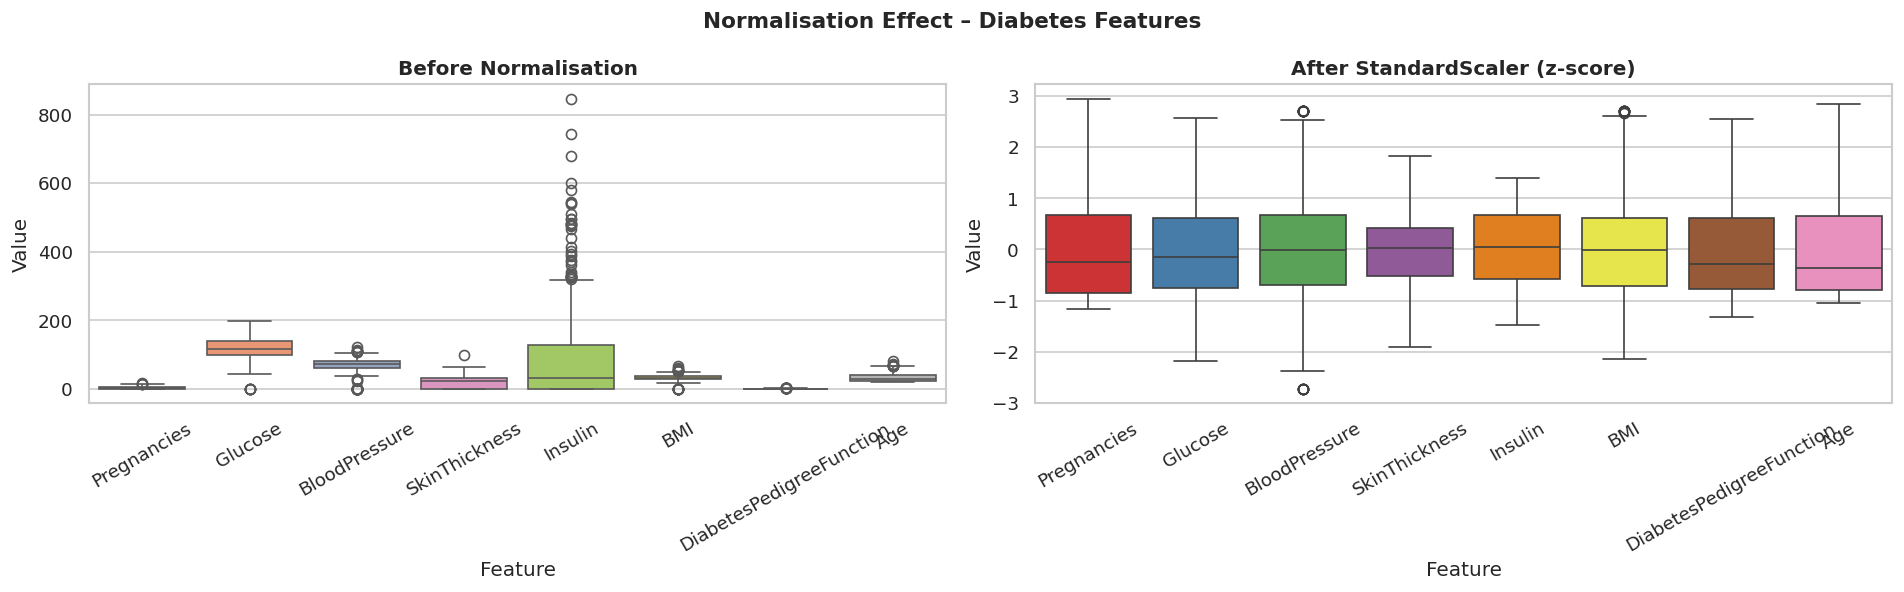

In [15]:
# Visualise normalisation effect
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

raw_melt  = diabetes_df[feats_d].melt(var_name='Feature', value_name='Value')
norm_melt = Xtr_d.melt(var_name='Feature', value_name='Value')

sns.boxplot(data=raw_melt,  x='Feature', y='Value', ax=axes[0], palette='Set2')
axes[0].set_title('Before Normalisation', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=norm_melt, x='Feature', y='Value', ax=axes[1], palette='Set1')
axes[1].set_title('After StandardScaler (z-score)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Normalisation Effect – Diabetes Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🤖 Step 5: Train Multiple Classification Models

In [16]:
MODELS = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=SEED),
    'Decision Tree':        DecisionTreeClassifier(max_depth=6, random_state=SEED),
    'Random Forest':        RandomForestClassifier(n_estimators=200, random_state=SEED),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    'AdaBoost':             AdaBoostClassifier(n_estimators=100, random_state=SEED),
    'SVM':                  SVC(kernel='rbf', probability=True, random_state=SEED),
    'K-Nearest Neighbours': KNeighborsClassifier(n_neighbors=7),
    'Naïve Bayes':          GaussianNB(),
}

def train_evaluate(models, X_train, X_test, y_train, y_test, dataset_name):
    results, trained = [], {}
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    print(f'\n{"─"*65}')
    print(f'  🏋️  Training on {dataset_name}')
    print(f'{"─"*65}')

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:,1]
        cv_sc   = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')

        row = {
            'Model':     name,
            'Accuracy':  accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall':    recall_score(y_test, y_pred, zero_division=0),
            'F1-Score':  f1_score(y_test, y_pred, zero_division=0),
            'ROC-AUC':   roc_auc_score(y_test, y_proba),
            'CV Mean':   cv_sc.mean(),
            'CV Std':    cv_sc.std(),
        }
        results.append(row)
        trained[name] = (model, y_pred, y_proba)
        print(f'  ✔ {name:<25} Acc={row["Accuracy"]:.3f}  AUC={row["ROC-AUC"]:.3f}  CV={row["CV Mean"]:.3f}±{row["CV Std"]:.3f}')

    res_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
    return res_df, trained

res_d, trained_d = train_evaluate(MODELS, Xtr_d, Xte_d, ytr_d, yte_d, 'Diabetes')
res_h, trained_h = train_evaluate(MODELS, Xtr_h, Xte_h, ytr_h, yte_h, 'Heart Disease')


─────────────────────────────────────────────────────────────────
  🏋️  Training on Diabetes
─────────────────────────────────────────────────────────────────
  ✔ Logistic Regression       Acc=0.708  AUC=0.807  CV=0.785±0.011
  ✔ Decision Tree             Acc=0.740  AUC=0.790  CV=0.707±0.028
  ✔ Random Forest             Acc=0.760  AUC=0.822  CV=0.770±0.017
  ✔ Gradient Boosting         Acc=0.766  AUC=0.814  CV=0.741±0.014
  ✔ AdaBoost                  Acc=0.760  AUC=0.818  CV=0.772±0.015
  ✔ SVM                       Acc=0.753  AUC=0.810  CV=0.780±0.014
  ✔ K-Nearest Neighbours      Acc=0.714  AUC=0.773  CV=0.761±0.012
  ✔ Naïve Bayes               Acc=0.708  AUC=0.790  CV=0.765±0.007

─────────────────────────────────────────────────────────────────
  🏋️  Training on Heart Disease
─────────────────────────────────────────────────────────────────
  ✔ Logistic Regression       Acc=0.820  AUC=0.895  CV=0.805±0.097
  ✔ Decision Tree             Acc=0.721  AUC=0.741  CV=0.744±0.097
  ✔ R

## 📊 Step 6: Model Evaluation & Comparison

In [17]:
# Styled leaderboard tables
metric_cols = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC','CV Mean']
fmt = {c: '{:.4f}' for c in metric_cols + ['CV Std']}

print('\n📋 Diabetes – Model Leaderboard')
display(res_d.style
    .background_gradient(cmap='RdYlGn', subset=metric_cols)
    .format(fmt)
    .set_caption('Diabetes Prediction'))

print('\n📋 Heart Disease – Model Leaderboard')
display(res_h.style
    .background_gradient(cmap='RdYlGn', subset=metric_cols)
    .format(fmt)
    .set_caption('Heart Disease Prediction'))


📋 Diabetes – Model Leaderboard


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Mean,CV Std
0,Random Forest,0.7597,0.6735,0.6111,0.6408,0.8217,0.7704,0.0173
1,AdaBoost,0.7597,0.6889,0.5741,0.6263,0.8180,0.7720,0.0148
2,Gradient Boosting,0.7662,0.6731,0.6481,0.6604,0.8137,0.7410,0.0143
3,SVM,0.7532,0.6818,0.5556,0.6122,0.8102,0.7801,0.0136
4,Logistic Regression,0.7078,0.6000,0.5000,0.5455,0.8074,0.7850,0.0115
5,Decision Tree,0.7403,0.6842,0.4815,0.5652,0.7905,0.7068,0.0280
6,Naïve Bayes,0.7078,0.5789,0.6111,0.5946,0.7904,0.7655,0.0067
7,K-Nearest Neighbours,0.7143,0.6042,0.5370,0.5686,0.7734,0.7606,0.0115



📋 Heart Disease – Model Leaderboard


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Mean,CV Std
0,Naïve Bayes,0.8689,0.8205,0.9697,0.8889,0.9058,0.8342,0.0964
1,Random Forest,0.8197,0.7619,0.9697,0.8533,0.9042,0.8263,0.0750
2,Logistic Regression,0.8197,0.7750,0.9394,0.8493,0.8950,0.8054,0.0968
3,SVM,0.8361,0.7805,0.9697,0.8649,0.8939,0.8219,0.0619
4,AdaBoost,0.8033,0.8000,0.8485,0.8235,0.8799,0.7975,0.0733
5,K-Nearest Neighbours,0.8361,0.7949,0.9394,0.8611,0.8761,0.8096,0.0614
6,Gradient Boosting,0.8033,0.7838,0.8788,0.8286,0.8712,0.7646,0.0872
7,Decision Tree,0.7213,0.7105,0.8182,0.7606,0.7408,0.7435,0.0971


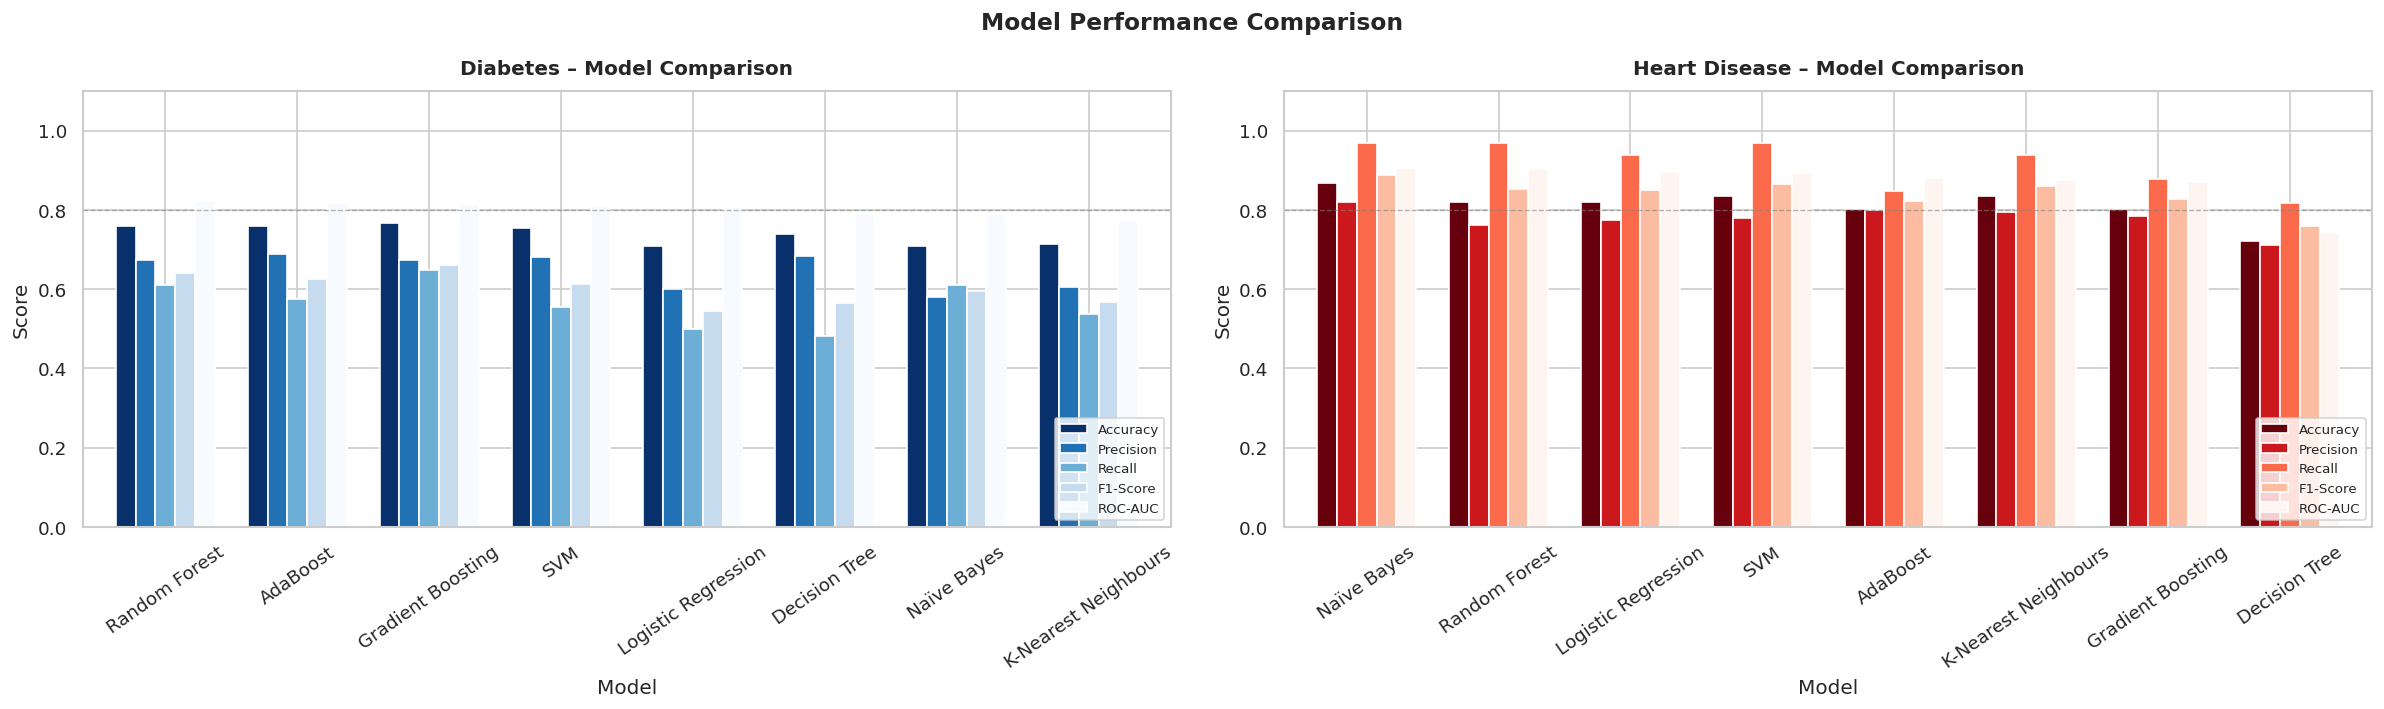

In [18]:
# Bar chart comparison
metrics = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, (res, title, cmap) in zip(axes, [
    (res_d, 'Diabetes',      'Blues_r'),
    (res_h, 'Heart Disease', 'Reds_r'),
]):
    res.set_index('Model')[metrics].plot(kind='bar', ax=ax, width=0.75,
                                          colormap=cmap, edgecolor='white')
    ax.set_title(f'{title} – Model Comparison', fontweight='bold', pad=10)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=35)
    ax.legend(loc='lower right', fontsize=8)
    ax.axhline(0.8, color='gray', linestyle='--', lw=0.8, alpha=0.6)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

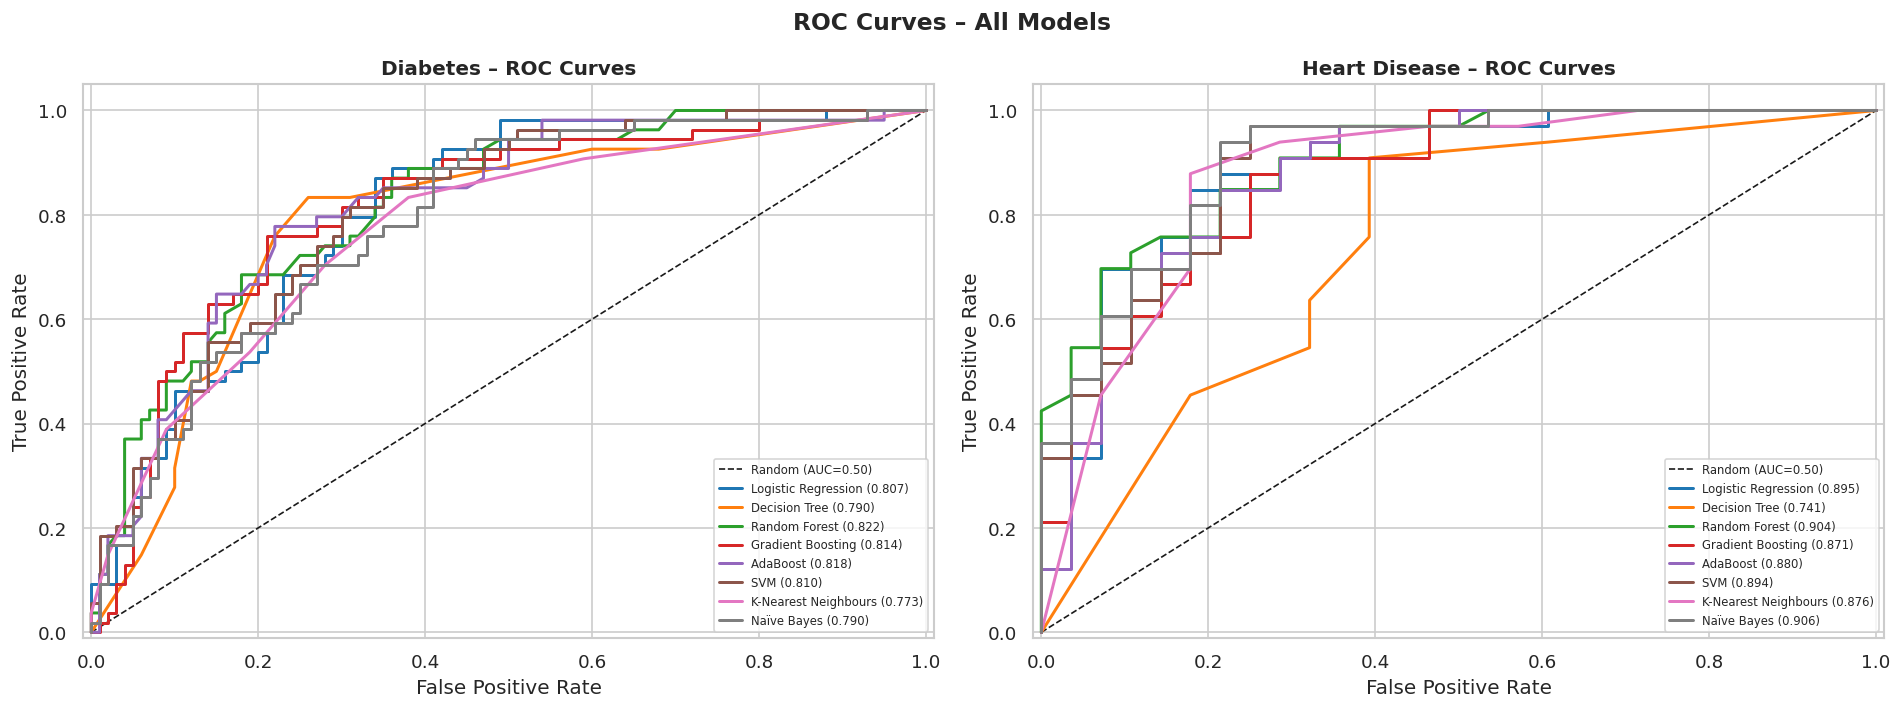

In [19]:
# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
COLORS = plt.cm.tab10.colors

for ax, (trained, y_test, title) in zip(axes, [
    (trained_d, yte_d, 'Diabetes'),
    (trained_h, yte_h, 'Heart Disease'),
]):
    ax.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.50)')
    for (name, (model, y_pred, y_proba)), color in zip(trained.items(), COLORS):
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        ax.plot(fpr, tpr, lw=1.8, color=color, label=f'{name} ({auc:.3f})')
    ax.set_title(f'{title} – ROC Curves', fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=7)
    ax.set_xlim([-0.01,1.01]); ax.set_ylim([-0.01,1.05])

plt.suptitle('ROC Curves – All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Best Diabetes model:      Random Forest
Best Heart Disease model: Naïve Bayes


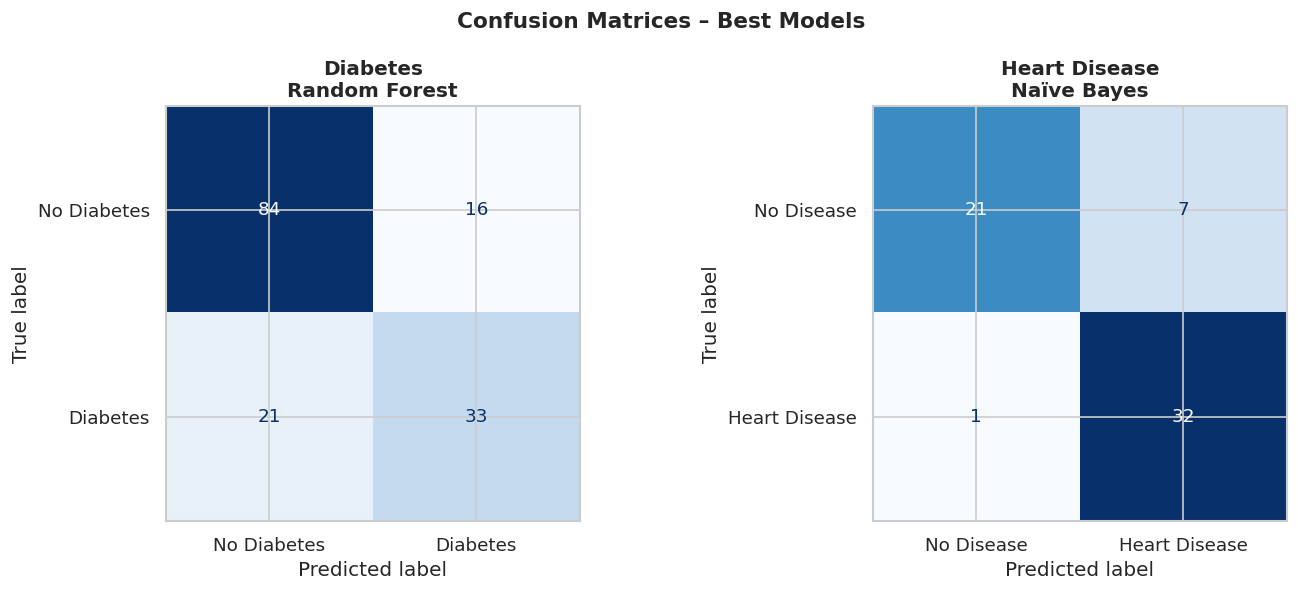

In [20]:
# Confusion matrices for best models
best_d = res_d.iloc[0]['Model']
best_h = res_h.iloc[0]['Model']
print(f'Best Diabetes model:      {best_d}')
print(f'Best Heart Disease model: {best_h}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, trained, y_test, labels, title) in zip(axes, [
    (best_d, trained_d, yte_d, ['No Diabetes','Diabetes'],      'Diabetes'),
    (best_h, trained_h, yte_h, ['No Disease','Heart Disease'],  'Heart Disease'),
]):
    _, y_pred, _ = trained[name]
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{title}\n{name}', fontweight='bold')

plt.suptitle('Confusion Matrices – Best Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# Classification reports
for name, trained, y_test, labels, title in [
    (best_d, trained_d, yte_d, ['No Diabetes','Diabetes'],     'Diabetes'),
    (best_h, trained_h, yte_h, ['No Disease','Heart Disease'], 'Heart Disease'),
]:
    _, y_pred, _ = trained[name]
    print(f'\n{"="*55}')
    print(f'  {title} – {name}')
    print(f'{"="*55}')
    print(classification_report(y_test, y_pred, target_names=labels))


  Diabetes – Random Forest
              precision    recall  f1-score   support

 No Diabetes       0.80      0.84      0.82       100
    Diabetes       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154


  Heart Disease – Naïve Bayes
               precision    recall  f1-score   support

   No Disease       0.95      0.75      0.84        28
Heart Disease       0.82      0.97      0.89        33

     accuracy                           0.87        61
    macro avg       0.89      0.86      0.86        61
 weighted avg       0.88      0.87      0.87        61



## 🔬 Step 7: Feature Importance & SHAP Analysis

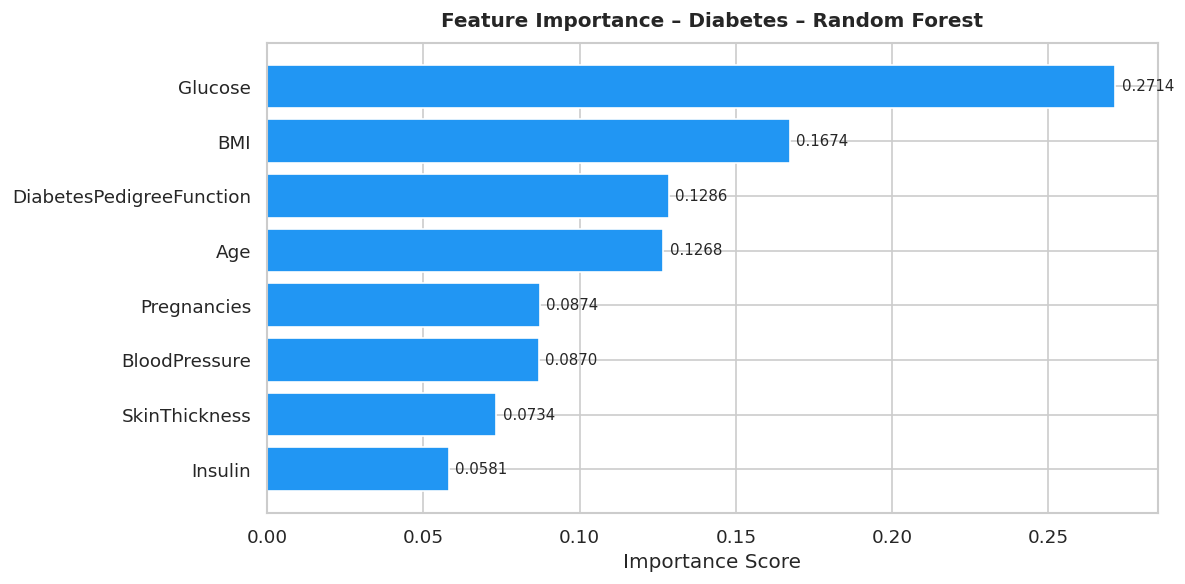

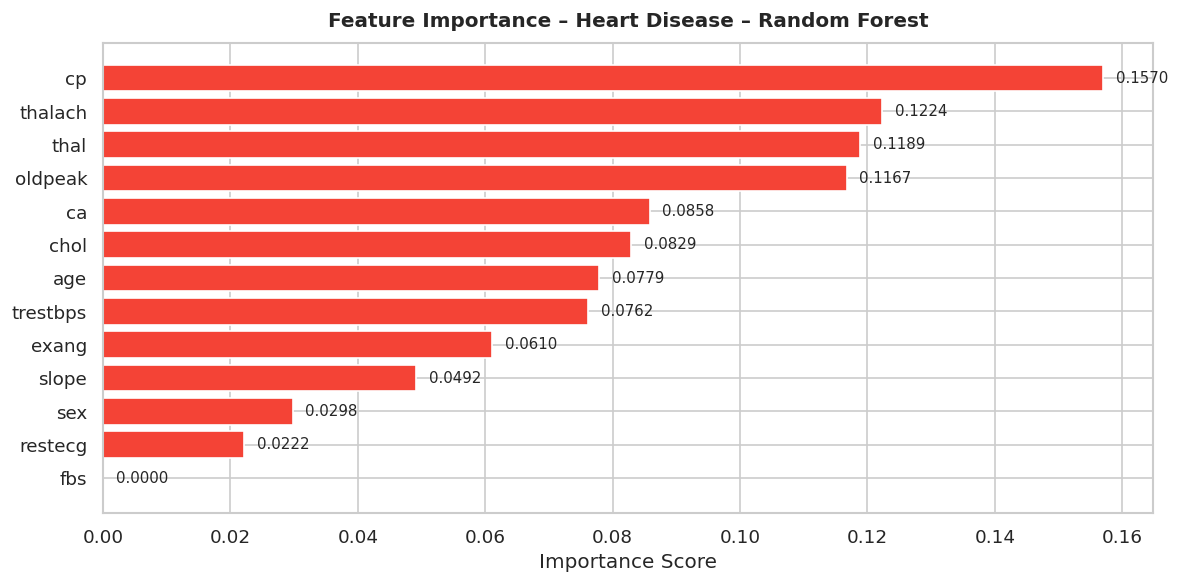

In [22]:
# Tree-based feature importances
def plot_feat_importance(model, feature_names, title, color):
    if hasattr(model, 'feature_importances_'):
        imps = model.feature_importances_
    elif hasattr(model, 'coef_'):
        imps = np.abs(model.coef_[0])
    else:
        print(f'  Importances not available for {title}'); return

    idx = np.argsort(imps)[::-1]
    sorted_feats = [feature_names[i] for i in idx]
    sorted_imps  = imps[idx]

    plt.figure(figsize=(10, 5))
    bars = plt.barh(sorted_feats[::-1], sorted_imps[::-1], color=color, edgecolor='white')
    plt.xlabel('Importance Score')
    plt.title(f'Feature Importance – {title}', fontweight='bold', pad=10)
    for bar, imp in zip(bars, sorted_imps[::-1]):
        plt.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
                 f'{imp:.4f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

# Train dedicated RF models for importance
rf_d = RandomForestClassifier(n_estimators=200, random_state=SEED).fit(Xtr_d, ytr_d)
rf_h = RandomForestClassifier(n_estimators=200, random_state=SEED).fit(Xtr_h, ytr_h)

plot_feat_importance(rf_d, feats_d, 'Diabetes – Random Forest',      '#2196F3')
plot_feat_importance(rf_h, feats_h, 'Heart Disease – Random Forest', '#F44336')

🔬 Computing SHAP values – Diabetes...


<Figure size 1200x720 with 0 Axes>

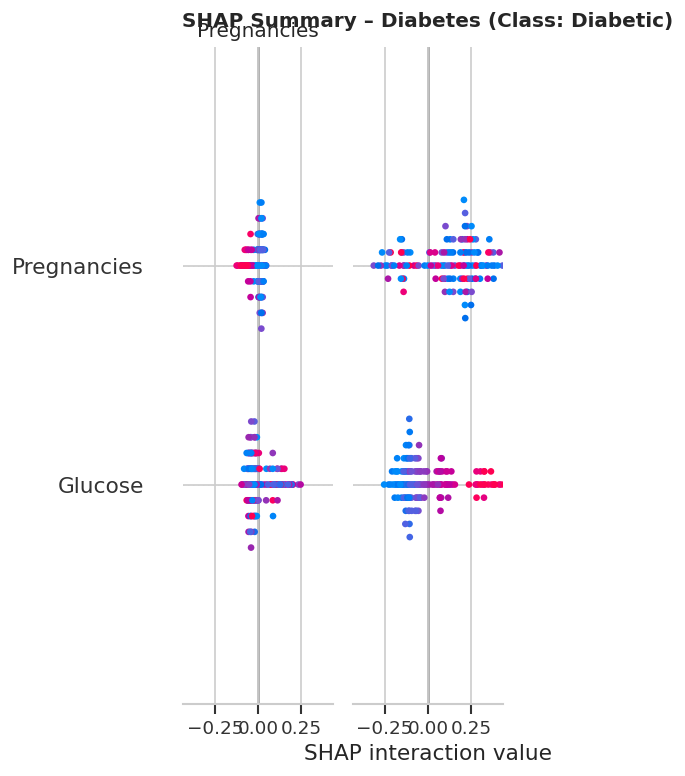

In [23]:
# SHAP – Diabetes
print('🔬 Computing SHAP values – Diabetes...')
explainer_d = shap.TreeExplainer(rf_d)
shap_vals_d = explainer_d.shap_values(Xte_d)
sv_d = shap_vals_d[1] if isinstance(shap_vals_d, list) else shap_vals_d

plt.figure(figsize=(10, 6))
shap.summary_plot(sv_d, Xte_d, feature_names=feats_d, show=False, plot_size=(10,6))
plt.title('SHAP Summary – Diabetes (Class: Diabetic)', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

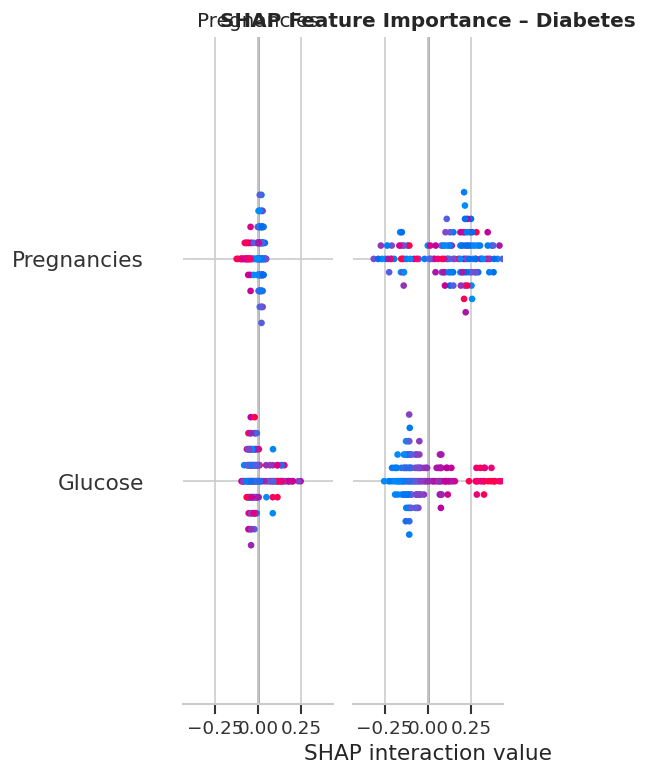

In [24]:
# SHAP bar – Diabetes
plt.figure(figsize=(10, 5))
shap.summary_plot(sv_d, Xte_d, feature_names=feats_d, plot_type='bar', show=False)
plt.title('SHAP Feature Importance – Diabetes', fontweight='bold')
plt.tight_layout()
plt.show()

🔬 Computing SHAP values – Heart Disease...


<Figure size 1200x720 with 0 Axes>

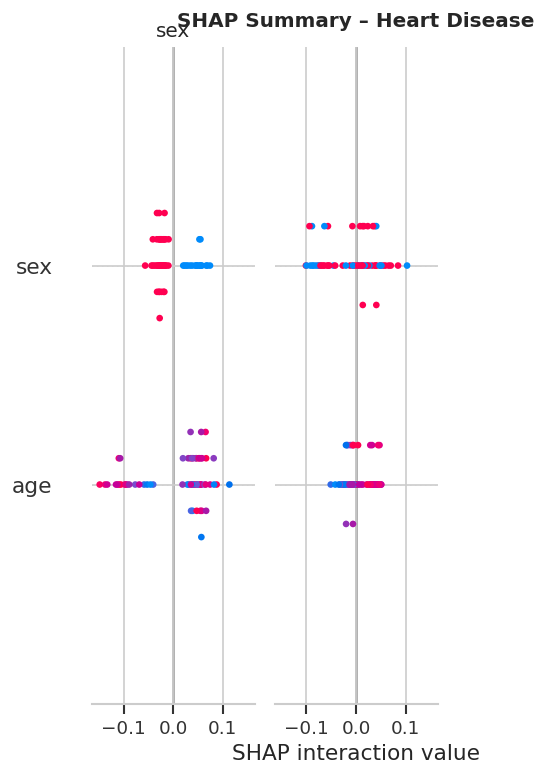

In [25]:
# SHAP – Heart Disease
print('🔬 Computing SHAP values – Heart Disease...')
explainer_h = shap.TreeExplainer(rf_h)
shap_vals_h = explainer_h.shap_values(Xte_h)
sv_h = shap_vals_h[1] if isinstance(shap_vals_h, list) else shap_vals_h

plt.figure(figsize=(10, 6))
shap.summary_plot(sv_h, Xte_h, feature_names=feats_h, show=False, plot_size=(10,6))
plt.title('SHAP Summary – Heart Disease', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

## 🔮 Step 8: Interactive Risk Prediction Tool

In [31]:
# Quick diagnostic — run this if predictor still fails
print("best_d:", best_d)
print("res_d best model:", res_d.iloc[0]['Model'])
print("trained_d keys:", list(trained_d.keys()))
print("feats_d:", feats_d)
print("feats_h:", feats_h)

m, _, _ = trained_d[res_d.iloc[0]['Model']]
print("Model n_features_in_:", m.n_features_in_)

best_d: Random Forest
res_d best model: Random Forest
trained_d keys: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'AdaBoost', 'SVM', 'K-Nearest Neighbours', 'Naïve Bayes']
feats_d: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
feats_h: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Model n_features_in_: 13


In [33]:
# ── FIX: Retrain dedicated diabetes Random Forest (isolated object)
from sklearn.ensemble import RandomForestClassifier

rf_diabetes_fixed = RandomForestClassifier(n_estimators=200, random_state=SEED)
rf_diabetes_fixed.fit(Xtr_d, ytr_d)

print(f'✅ Diabetes RF retrained on {rf_diabetes_fixed.n_features_in_} features: {feats_d}')

✅ Diabetes RF retrained on 8 features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [34]:
# ─────────────────────────────────────────────────
#  🔮 DIABETES RISK PREDICTOR (uses fixed model)
# ─────────────────────────────────────────────────
patient_diabetes = {
    'Pregnancies':               2,
    'Glucose':                 120,
    'BloodPressure':            70,
    'SkinThickness':            25,
    'Insulin':                  80,
    'BMI':                    28.5,
    'DiabetesPedigreeFunction': 0.45,
    'Age':                      35,
}

p_df = pd.DataFrame([patient_diabetes])[feats_d]
p_sc = scaler_d.transform(p_df)

prob = rf_diabetes_fixed.predict_proba(p_sc)[0][1]
pred = rf_diabetes_fixed.predict(p_sc)[0]
risk = '🟢 LOW' if prob < 0.30 else ('🟡 MODERATE' if prob < 0.60 else '🔴 HIGH')

print('='*55)
print('  🏥 DIABETES RISK ASSESSMENT')
print('='*55)
for k, v in patient_diabetes.items():
    print(f'  {k:<35} {v}')
print('-'*55)
print(f'  Model:            Random Forest (Diabetes)')
print(f'  Risk Probability: {prob*100:.1f}%')
print(f'  Risk Level:       {risk}')
print(f'  Prediction:       {"⚠️  Diabetic" if pred==1 else "✅ Non-Diabetic"}')
print('='*55)
print('  ⚠️  Educational purposes only — consult a physician.')

  🏥 DIABETES RISK ASSESSMENT
  Pregnancies                         2
  Glucose                             120
  BloodPressure                       70
  SkinThickness                       25
  Insulin                             80
  BMI                                 28.5
  DiabetesPedigreeFunction            0.45
  Age                                 35
-------------------------------------------------------
  Model:            Random Forest (Diabetes)
  Risk Probability: 31.5%
  Risk Level:       🟡 MODERATE
  Prediction:       ✅ Non-Diabetic
  ⚠️  Educational purposes only — consult a physician.


In [35]:
# ─────────────────────────────────────────────────
#  🫀 HEART DISEASE RISK PREDICTOR
#  age, sex(1=M/0=F), cp(0-3), trestbps, chol,
#  fbs(1/>120mg), restecg(0-2), thalach, exang(1=yes),
#  oldpeak, slope(0-2), ca(0-3), thal(1-3)
# ─────────────────────────────────────────────────
patient_heart = {
    'age':      52, 'sex':       1, 'cp':        2,
    'trestbps':130, 'chol':    240, 'fbs':       0,
    'restecg':   1, 'thalach': 160, 'exang':     0,
    'oldpeak': 1.5, 'slope':     1, 'ca':        0,
    'thal':      2,
}

ph_df = pd.DataFrame([patient_heart]).reindex(columns=feats_h, fill_value=np.nan)
ph_sc  = scaler_h.transform(ph_df)

best_model_h, _, _ = trained_h[best_h]
prob_h = best_model_h.predict_proba(ph_sc)[0][1]
pred_h = best_model_h.predict(ph_sc)[0]
risk_h = '🟢 LOW' if prob_h < 0.30 else ('🟡 MODERATE' if prob_h < 0.60 else '🔴 HIGH')

print('='*55)
print('  🫀 HEART DISEASE RISK ASSESSMENT')
print('='*55)
for k, v in patient_heart.items():
    print(f'  {k:<35} {v}')
print('-'*55)
print(f'  Model:            {best_h}')
print(f'  Risk Probability: {prob_h*100:.1f}%')
print(f'  Risk Level:       {risk_h}')
print(f'  Prediction:       {"⚠️  Heart Disease" if pred_h==1 else "✅ No Heart Disease"}')
print('='*55)
print('  ⚠️  Educational purposes only — consult a physician.')

  🫀 HEART DISEASE RISK ASSESSMENT
  age                                 52
  sex                                 1
  cp                                  2
  trestbps                            130
  chol                                240
  fbs                                 0
  restecg                             1
  thalach                             160
  exang                               0
  oldpeak                             1.5
  slope                               1
  ca                                  0
  thal                                2
-------------------------------------------------------
  Model:            Naïve Bayes
  Risk Probability: 98.0%
  Risk Level:       🔴 HIGH
  Prediction:       ⚠️  Heart Disease
  ⚠️  Educational purposes only — consult a physician.


In [36]:
# Risk gauge charts (Plotly)
def risk_gauge(probability, title):
    fig = go.Figure(go.Indicator(
        mode  = 'gauge+number',
        value = probability * 100,
        number= {'suffix': '%', 'font': {'size': 36}},
        title = {'text': title, 'font': {'size': 16}},
        gauge = {
            'axis': {'range': [0, 100]},
            'bar':  {'color': '#1565C0'},
            'steps': [
                {'range': [0,   30], 'color': '#C8E6C9'},
                {'range': [30,  60], 'color': '#FFF9C4'},
                {'range': [60, 100], 'color': '#FFCDD2'},
            ],
            'threshold': {'line': {'color': 'black', 'width': 3},
                          'thickness': 0.8, 'value': probability*100}
        }
    ))
    fig.update_layout(height=300, margin=dict(l=30,r=30,t=60,b=20))
    fig.show()

risk_gauge(prob,   '🏥 Diabetes Risk')
risk_gauge(prob_h, '🫀 Heart Disease Risk')

## 🔒 Step 9: Ethical Data Handling & Patient Privacy

In [37]:
ethical_framework = """
╔══════════════════════════════════════════════════════════════════════════════╗
║           🔒 ETHICAL FRAMEWORK – HEALTHCARE PREDICTIVE ANALYTICS           ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  1. PATIENT PRIVACY & DATA ANONYMISATION                                    ║
║     • Remove all identifiers (name, SSN, MRN) before modelling.            ║
║     • Apply k-anonymity / differential privacy where feasible.              ║
║     • Comply with HIPAA (US), GDPR (EU), DISHA (India).                     ║
║                                                                              ║
║  2. INFORMED CONSENT & DATA GOVERNANCE                                      ║
║     • Use data only for purposes patients have consented to.                ║
║     • Maintain audit trails for every data access event.                    ║
║     • Use only IRB-approved datasets in production.                         ║
║                                                                              ║
║  3. BIAS DETECTION & FAIRNESS                                               ║
║     • Audit model performance across demographic groups.                    ║
║     • Use fairness metrics: equalised odds, demographic parity.             ║
║     • Avoid training on datasets that under-represent minorities.           ║
║                                                                              ║
║  4. MODEL TRANSPARENCY (XAI)                                                ║
║     • Prefer interpretable models when clinically possible.                 ║
║     • Use SHAP / LIME for black-box explanations.                           ║
║     • Clinicians must understand and validate model reasoning.              ║
║                                                                              ║
║  5. HUMAN-IN-THE-LOOP                                                       ║
║     • AI must ASSIST, never REPLACE, clinical judgement.                    ║
║     • All high-stakes decisions require human review.                       ║
║                                                                              ║
║  6. DATA SECURITY                                                           ║
║     • Encrypt at rest (AES-256) and in transit (TLS 1.3).                  ║
║     • Role-based access controls (RBAC) enforced.                          ║
║     • Regular penetration testing and vulnerability scans.                 ║
║                                                                              ║
║  7. MODEL MONITORING & DRIFT DETECTION                                      ║
║     • Monitor for data drift and concept drift over time.                  ║
║     • Re-train models with updated patient data periodically.              ║
║     • Maintain model versioning and rollback capability.                   ║
║                                                                              ║
║  8. EDUCATIONAL DISCLAIMER                                                  ║
║     • This notebook uses publicly available de-identified data.            ║
║     • Results are STRICTLY for educational / research use only.            ║
║     • NOT intended for clinical use or medical diagnosis.                  ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""
print(ethical_framework)


╔══════════════════════════════════════════════════════════════════════════════╗
║           🔒 ETHICAL FRAMEWORK – HEALTHCARE PREDICTIVE ANALYTICS           ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  1. PATIENT PRIVACY & DATA ANONYMISATION                                    ║
║     • Remove all identifiers (name, SSN, MRN) before modelling.            ║
║     • Apply k-anonymity / differential privacy where feasible.              ║
║     • Comply with HIPAA (US), GDPR (EU), DISHA (India).                     ║
║                                                                              ║
║  2. INFORMED CONSENT & DATA GOVERNANCE                                      ║
║     • Use data only for purposes patients have consented to.                ║
║     • Maintain audit trails for every data access event.                    ║
║     • Use only IRB-approved datasets

📊 Fairness Audit – Accuracy by Age Group (Diabetes)



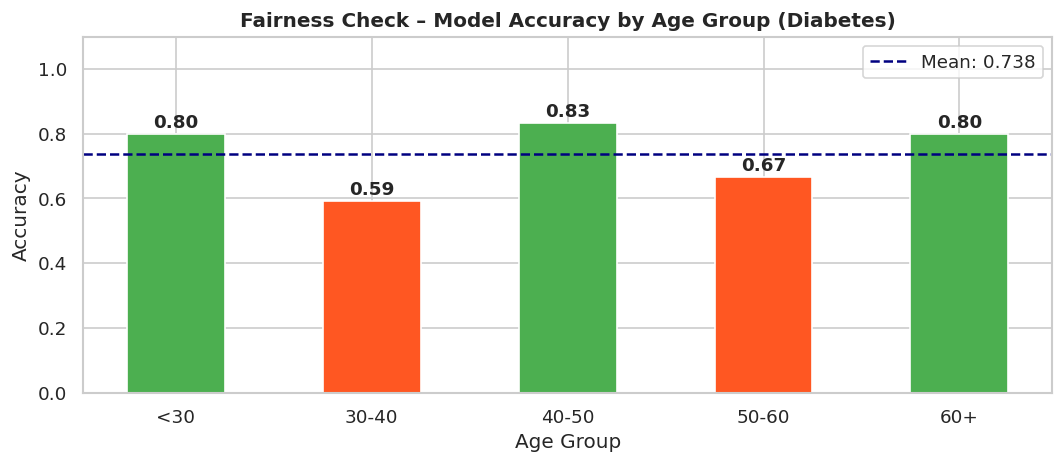

AgeGroup
<30      0.797753
30-40    0.592593
40-50    0.833333
50-60    0.666667
60+      0.800000


In [39]:
# 📊 Fairness Audit – Accuracy by Age Group (Diabetes)
print('📊 Fairness Audit – Accuracy by Age Group (Diabetes)\n')

X_test_orig = pd.DataFrame(scaler_d.inverse_transform(Xte_d), columns=feats_d)
y_pred_all  = rf_diabetes_fixed.predict(Xte_d)   # ← use the fixed diabetes model

bias_df = X_test_orig[['Age']].copy()
bias_df['True']      = yte_d.values
bias_df['Predicted'] = y_pred_all
bias_df['Correct']   = (bias_df['True'] == bias_df['Predicted']).astype(int)
bias_df['AgeGroup']  = pd.cut(bias_df['Age'],
                               bins=[0,30,40,50,60,120],
                               labels=['<30','30-40','40-50','50-60','60+'])
group_acc = bias_df.groupby('AgeGroup', observed=True)['Correct'].mean()

plt.figure(figsize=(9, 4))
bars = plt.bar(group_acc.index.astype(str), group_acc.values,
               color=['#4CAF50' if v >= 0.75 else '#FF5722' for v in group_acc.values],
               edgecolor='white', width=0.5)
plt.axhline(group_acc.mean(), color='navy', linestyle='--', lw=1.5,
            label=f'Mean: {group_acc.mean():.3f}')
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
plt.xlabel('Age Group')
plt.title('Fairness Check – Model Accuracy by Age Group (Diabetes)', fontweight='bold')
for bar, val in zip(bars, group_acc.values):
    plt.text(bar.get_x()+bar.get_width()/2, val+0.02, f'{val:.2f}',
             ha='center', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()
print(group_acc.to_string())

## 📝 Step 10: Final Summary

In [40]:
print('\n' + '='*65)
print('  🏥  HEALTHCARE PREDICTIVE ANALYTICS – PROJECT SUMMARY')
print('='*65)

print('\n  📂 Datasets')
print(f'     • Pima Indians Diabetes  →  {diabetes_df.shape[0]} patients, {len(feats_d)} features')
print(f'     • Cleveland Heart Disease → {heart_df.shape[0]} patients, {len(feats_h)} features')

print('\n  🤖 Models Trained')
for m in MODELS: print(f'     • {m}')

print('\n  🏆 Best – Diabetes')
r = res_d.iloc[0]
print(f'     {r["Model"]}  |  Acc={r["Accuracy"]:.4f}  AUC={r["ROC-AUC"]:.4f}  F1={r["F1-Score"]:.4f}')

print('\n  🏆 Best – Heart Disease')
r = res_h.iloc[0]
print(f'     {r["Model"]}  |  Acc={r["Accuracy"]:.4f}  AUC={r["ROC-AUC"]:.4f}  F1={r["F1-Score"]:.4f}')

print('\n  🔬 Techniques Applied')
for t in [
    'Direct URL dataset loading (no API dependency)',
    'Median imputation of biologically-impossible zeros',
    'IQR-based outlier clipping (winsorization)',
    'StandardScaler normalisation (fit on train only)',
    'Stratified K-Fold Cross Validation (k=5)',
    'SHAP explainability (TreeExplainer)',
    'Fairness audit across age demographic groups',
    'Multi-metric evaluation: Accuracy, AUC, F1, Recall',
]:
    print(f'     ✔ {t}')

print('\n  ⚠️  For educational purposes only.')
print('  Consult a licensed medical professional for health decisions.')
print('='*65)


  🏥  HEALTHCARE PREDICTIVE ANALYTICS – PROJECT SUMMARY

  📂 Datasets
     • Pima Indians Diabetes  →  768 patients, 8 features
     • Cleveland Heart Disease → 303 patients, 13 features

  🤖 Models Trained
     • Logistic Regression
     • Decision Tree
     • Random Forest
     • Gradient Boosting
     • AdaBoost
     • SVM
     • K-Nearest Neighbours
     • Naïve Bayes

  🏆 Best – Diabetes
     Random Forest  |  Acc=0.7597  AUC=0.8217  F1=0.6408

  🏆 Best – Heart Disease
     Naïve Bayes  |  Acc=0.8689  AUC=0.9058  F1=0.8889

  🔬 Techniques Applied
     ✔ Direct URL dataset loading (no API dependency)
     ✔ Median imputation of biologically-impossible zeros
     ✔ IQR-based outlier clipping (winsorization)
     ✔ StandardScaler normalisation (fit on train only)
     ✔ Stratified K-Fold Cross Validation (k=5)
     ✔ SHAP explainability (TreeExplainer)
     ✔ Fairness audit across age demographic groups
     ✔ Multi-metric evaluation: Accuracy, AUC, F1, Recall

  ⚠️  For educational 